In [1]:
%pwd

'd:\\Tipto\\OmniChef-Nexus\\notebooks'

In [2]:
import os
os.chdir("../")

In [3]:
%pwd

'd:\\Tipto\\OmniChef-Nexus'

In [4]:
import warnings
warnings.filterwarnings('ignore' , category = FutureWarning)

In [5]:
import torch
from transformers import AutoModel , AutoProcessor
from transformers.image_utils import load_image
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [6]:
# load the dataset
IMAGE_DIR = "data/output/images"

from datasets import load_dataset

dataset = load_dataset(
    "imagefolder",
    data_dir = IMAGE_DIR,
    split = 'train'
)
dataset

Resolving data files:   0%|          | 0/15699 [00:00<?, ?it/s]

Dataset({
    features: ['image', 'name', 'minutes', 'tags', 'nutrition', 'n_steps', 'steps', 'description', 'ingredients', 'n_ingredients', 'recipe_id', 'rating', 'review', 'num_of_ratings', 'markdown_recipe'],
    num_rows: 15698
})

In [8]:
# save the dataset on disk
dataset.save_to_disk("data/dataset/")

Saving the dataset (0/16 shards):   0%|          | 0/15698 [00:00<?, ? examples/s]

In [6]:
from PIL import Image
from safetensors.torch import load_file
from datasets import load_from_disk , load_dataset

In [7]:
dataset = load_dataset(
    "tiptoghosh/food-recipes-15k" , split = "train"
)
dataset

Repo card metadata block was not found. Setting CardData to empty.


Resolving data files:   0%|          | 0/32 [00:00<?, ?it/s]

data/train-00000-of-00032.parquet:   0%|          | 0.00/488M [00:00<?, ?B/s]

data/train-00001-of-00032.parquet:   0%|          | 0.00/490M [00:00<?, ?B/s]

data/train-00002-of-00032.parquet:   0%|          | 0.00/487M [00:00<?, ?B/s]

...

data/train-00030-of-00032.parquet:   0%|          | 0.00/487M [00:00<?, ?B/s]

data/train-00031-of-00032.parquet:   0%|          | 0.00/484M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15698 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/27 [00:00<?, ?it/s]

Dataset({
    features: ['name', 'recipe_id', 'minutes', 'description', 'tags', 'steps', 'n_steps', 'n_ingredients', 'nutrition', 'rating', 'num_ratings', 'markdown', 'image'],
    num_rows: 15698
})

In [8]:
# load the embedding model with a specific revision version
model_name = "nvidia/llama-nemotron-embed-vl-1b-v2"
revision = "062ffaa1e3d24a8a50bd6a7ac7b8e54103e1f01d"

embedding_model = AutoModel.from_pretrained(
    model_name,
    revision = revision,
    dtype = torch.float16,
    trust_remote_code = True,
    attn_implementation = "flash_attention_2",
    device_map = "auto"
).eval()

Loading weights:   0%|          | 0/600 [00:00<?, ?it/s]

In [9]:
# make a helper function to change the model's modality
def prepare_processor(modality , embedding_model):
    """Prepare the model for different modality.

    Args:
        modality (str): can be 'text' , 'image' or 'image_text'
        embedding_model (_type_): embedding model

    Returns:
        _type_: (modality , embedding_model)
    """
    # Set max number of tokens (p_max_length) based on modality
    if modality == "image":
        p_max_length = 2048
    elif modality == "image_text":
        p_max_length = 10240
    elif modality == "text":
        p_max_length = 8192
    embedding_model.processor.p_max_length = p_max_length
    # Image specific settings(only matter if image is present)
    # Sets max number of tiles an image can be split. Each tile consumes 256 tokens.
    embedding_model.processor.max_input_tiles = 6
    # Enables an extra tile with the full image at lower resolution
    embedding_model.processor.use_thumbnail = True
    return modality , embedding_model

In [25]:
class RecipeRetriever:
    def __init__(self , 
        dataset = None , 
        embedding_path = "data/embedding_tensors/all_recipes_image_text_embeddings.safetensors"
    ):
        # load the dataset from local imagefolder directory
        self.dataset = dataset
        
        if self.dataset is None:
            raise ValueError("RecipeRetriever was initialized without a dataset. Please provide one.")
        # load the embeddings
        self.target_embeddings = load_file(embedding_path)["image_text_embeddings"]
        if self.target_embeddings is None:
            raise ValueError("RecipeRetriever was initialized without embedding vectors. Please provide one.")
    
    def _l2_normalize(self , x: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
        if not isinstance(x, torch.Tensor):
            x = torch.tensor(x)
        return x / (x.norm(p=2, dim=-1, keepdim=True) + eps)

    def match_query(self, text_query = None, image_query = None, top_k = 5):
        global embedding_model
        
        # set modality based on query
        if text_query and image_query:
            modality = "image_text"
        elif text_query:
            modality = "text"
        elif image_query:
            modality = "image"
        else:
            raise ValueError("At least one query (text or image) must be provided.")

        modality, embedding_model = prepare_processor(
            modality = modality, 
            embedding_model = embedding_model
        )
        
        # create query embedding
        with torch.inference_mode(): 
            if modality == "text":
                query_embedding = embedding_model.encode_queries([text_query])
            elif modality == "image":
                query_embedding = embedding_model.encode_documents(images = [image_query])
            elif modality == "image_text":
                query_embedding = embedding_model.encode_documents(
                    texts = [text_query], 
                    images = [image_query]
                )

        device = self.target_embeddings.device
        query_embedding = query_embedding.to(device)
        
        # Similarity score 
        scores_matrix = self._l2_normalize(query_embedding) @ self._l2_normalize(self.target_embeddings).T
        scores_flat = scores_matrix.flatten()

        # Get Top K
        k_val = min(top_k, scores_flat.size(0))
        top_scores , top_indices = torch.topk(scores_flat, k = k_val)
        
        # Map back to Dataset
        results = []
        for i in range(k_val):
            idx = top_indices[i].item()
            recipe_data = self.dataset[idx] 
            
            results.append({
                "rank": i + 1,
                "score": top_scores[i].item(),
                "recipe": recipe_data
            })
            
        return results

In [26]:
dataset

Dataset({
    features: ['name', 'recipe_id', 'minutes', 'description', 'tags', 'steps', 'n_steps', 'n_ingredients', 'nutrition', 'rating', 'num_ratings', 'markdown', 'image'],
    num_rows: 15698
})

In [27]:
rr = RecipeRetriever(dataset = dataset)

In [28]:
results = rr.match_query(
    text_query = "recipe for apple pie"
)

In [29]:
rr.target_embeddings

tensor([[-0.9507,  1.1211,  2.6562,  ..., -2.3281, -0.3948,  0.0395],
        [-1.1504,  0.4902,  2.0195,  ...,  0.7817, -1.3008,  0.6104],
        [-0.1017, -1.1660,  0.9277,  ..., -1.5869, -2.0918, -0.8267],
        ...,
        [-0.7588,  1.2119,  1.5850,  ...,  0.6348, -1.9834, -0.1635],
        [-0.5239, -0.4646, -0.3879,  ..., -0.8237, -1.7998,  0.6162],
        [ 0.2712, -0.6646,  1.5234,  ..., -0.1637, -1.3701, -1.0488]],
       dtype=torch.float16)

In [30]:
print(results[0]['recipe']['markdown'])

# Five Star Apple Pie
**Recipe ID:** 16345
**Cook Time:** 65 minutes
**Rating:** 4.73/5 stars (11 reviews)

## Description
this secret of this decadent apple pie is brewing the sweet mixture of brown sugar, cinnamon, nutmeg, butter and apples before putting it in the oven. you'll enjoy having this pie in your cooking arsenal.

## Ingredients
granny smith apples, brown sugar, water, lemon juice, flour, sugar, salt, vanilla, butter, nutmeg, cinnamon, pastry for a double-crust 9-inch pie

## Instructions
1. Combine apples , brown sugar , water and lemon juice in a pot
2. Cover and cook over medium heat about five minutes or until the apples are just tender
3. Mix flour , granulated sugar , nutmeg , cinnamon and salt and stir into apple mixture
4. Cook , stirring constantly until the syrup thickens- about 2 minutes
5. Remove from heat and stir in the vanilla and butter
6. Heat oven to 425 degrees
7. Prepare pastry
8. Turn the apple mixture into the pastry-lined pie pan
9. Cover with top cr

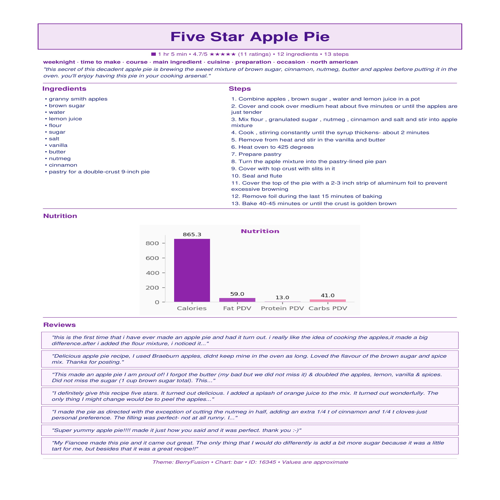

In [31]:
results[0]['recipe']['image'].resize(size = (500 , 500))

### app.py file

In [34]:
dataset

Dataset({
    features: ['name', 'recipe_id', 'minutes', 'description', 'tags', 'steps', 'n_steps', 'n_ingredients', 'nutrition', 'rating', 'num_ratings', 'markdown', 'image'],
    num_rows: 15698
})

In [36]:
raw_results = rr.match_query(
    text_query = "recipe for salad", 
    image_query = None, 
    top_k = 6
)

In [45]:
sample_recipe = raw_results[0]['recipe']

In [47]:
sample_recipe.keys()

dict_keys(['name', 'recipe_id', 'minutes', 'description', 'tags', 'steps', 'n_steps', 'n_ingredients', 'nutrition', 'rating', 'num_ratings', 'markdown', 'image'])

In [50]:
import gradio as gr 

retriever = RecipeRetriever(dataset = dataset)

def run_omni_search(text_query, image_query):
    if not text_query and image_query is None:
        return "Please provide at least a text description or an image."
    

    raw_results = retriever.match_query(
        text_query=text_query, 
        image_query=image_query, 
        top_k=6
    )
    
    
    gallery_items = []
    recipe_details = ""
    
    for res in raw_results:
        recipe = res['recipe']
        score = res['score']
        
        # Add to Gallery
        gallery_items.append((recipe['image'], f"Match Score: {score:.2f}"))
        
        # Add to Markdown Details
        # recipe_details += f"### {res['rank']}. {recipe['name']}\n"
        # recipe_details += f"**Ingredients:** {recipe['ingredients']}\n\n"
        # recipe_details += f"{recipe['markdown']}\n"
        # recipe_details += "---\n"
        recipe_details += f"{recipe['markdown']}\n"
        
    return gallery_items, recipe_details

In [51]:
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🍳 OmniChef-Nexus: Multimodal Recipe RAG")
    gr.Markdown("Search for recipes using text, images, or both!")
    
    with gr.Row():
        with gr.Column(scale=1):
            text_input = gr.Textbox(label="Describe what you want to cook...", placeholder="e.g., 'A healthy chicken salad with avocado'")
            image_input = gr.Image(label="Or upload a photo of ingredients", type="pil")
            search_btn = gr.Button("Find Recipes", variant="primary")
            
        with gr.Column(scale=2):
            result_gallery = gr.Gallery(label="Top Matches", columns=3, height="auto")
    
    gr.Markdown("## Detailed Instructions")
    recipe_output = gr.Markdown("Search results will appear here...")

    search_btn.click(
        fn=run_omni_search,
        inputs=[text_input, image_input],
        outputs=[result_gallery, recipe_output]
    )

demo.launch(theme = gr.themes.Soft())

C:\Users\tipto\AppData\Local\Temp\ipykernel_13984\3290350686.py:1: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


* Running on local URL:  http://127.0.0.1:7863
* To create a public link, set `share=True` in `launch()`.


help
